# **HW3 GMM, PCA and LDA**

1. **Chantouch Orungrote | 66340500011**
2. **Sasish Kaewsing | 66340500076**

---

## **Chapter 01**
### **Hello Soft Clustering (GMM)**
### **1. Gaussian with means (3,3), (2,2), (-3,-3)**

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
x_points = np.array([1, 3, 2, 8, 6, 7, -3, -2, -7])
y_points = np.array([2, 3, 2, 8, 6, 7, -3, -4, -7])
X = np.column_stack([x_points, y_points])
X.shape

(9, 2)

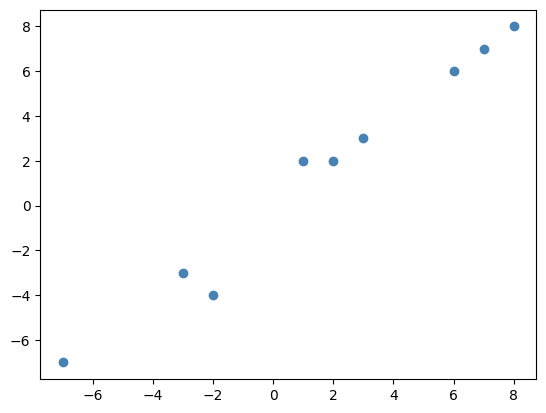

In [47]:
plt.scatter(x_points, y_points, c='steelblue')

In [48]:
from scipy.stats import multivariate_normal # PDF calculation

CONFIG = { 
    'gmm3' : { 'K': 3, 'init_means': [[3,3],[2,2],[-3,-3]] }, 
    'gmm2' : { 'K': 2, 'init_means': [[3,3],[3,-3]] }, 
    'n_iter' : 3, 
    'grid_range': (-12, 12), 
    'grid_size' : 300 
    }

In [49]:
def init_params(init_means, k, dim):
    phi = np.full(k, 1.0 / k, dtype=float) # equal weights
    mu = np.array(init_means, dtype=float) # initial means
    sigma = [np.eye(dim, dtype=float) for _ in range(k)] # identity cov
    return phi, mu, sigma

def e_step(X, mu, sigma, phi, eps=1e-12):
    n, k = X.shape[0], len(phi)
    P = np.empty((n, k), dtype=float) # pdf per component

    for j in range(k):
        rv = multivariate_normal(mean=mu[j], cov=sigma[j], allow_singular=False)
        P[:, j] = rv.pdf(X)

    W = P * phi # weighted pdf
    den = W.sum(axis=1, keepdims=True)
    den = np.clip(den, eps, None) # avoid divide by 0
    W = W / den # normalize
    return W, P

def m_step(X, W, covariance_type="diag", reg_covar=1e-6):
    n, dim = X.shape
    k = W.shape[1]
    phi = W.mean(axis=0) # update weights
    mu = np.zeros((k, dim), dtype=float)
    sigma = []

    for j in range(k):
        w = W[:, j]
        w_sum = w.sum()

        if w_sum <= 1e-12:
            raise ValueError(f"Component {j} collapsed")

        mu_j = (w[:, None] * X).sum(axis=0) / w_sum
        mu[j] = mu_j

        diff = X - mu_j
        cov_j = (w[:, None] * diff).T @ diff / w_sum # weighted cov

        if covariance_type == "diag":
            cov_j = np.diag(np.diag(cov_j)) # keep diagonal only
        elif covariance_type != "full":
            raise ValueError("covariance_type must be 'diag' or 'full'")

        cov_j += reg_covar * np.eye(dim) # small regularizer
        sigma.append(cov_j)

    return phi, mu, sigma

def compute_log_likelihood(X, phi, mu, sigma, eps=1e-12):
    n, k = X.shape[0], len(phi)
    P = np.empty((n, k), dtype=float)

    for j in range(k):
        rv = multivariate_normal(mean=mu[j], cov=sigma[j], allow_singular=False)
        P[:, j] = rv.pdf(X)

    mix_pdf = P @ phi
    mix_pdf = np.clip(mix_pdf, eps, None) # avoid log(0)
    return np.sum(np.log(mix_pdf))

def run_em(X, init_means, k, n_iter=10, covariance_type="diag", reg_covar=1e-6):
    dim = X.shape[1]
    phi, mu, sigma = init_params(init_means, k, dim)
    history = []

    for it in range(1, n_iter + 1):
        W, _ = e_step(X, mu, sigma, phi)
        phi, mu, sigma = m_step(X, W, covariance_type=covariance_type, reg_covar=reg_covar)
        ll = compute_log_likelihood(X, phi, mu, sigma)

        history.append({
            "W": W.copy(),
            "phi": phi.copy(),
            "mu": mu.copy(),
            "sigma": [s.copy() for s in sigma],
            "ll": float(ll)
        }) # save snapshot

        print("\n" + "=" * 72)
        print(f"Iteration {it} | K={k} | log L = {ll:.10f}")
        print("=" * 72)
        print(f"{'j':>2} | {'m_j':>10} | {'mu_j':>28} | {'diag(Sigma_j)':>28}")
        print("-" * 72)

        for j in range(k):
            mu_str = np.array2string(mu[j], precision=6, floatmode='fixed')
            sig_str = np.array2string(np.diag(sigma[j]), precision=6, floatmode='fixed')
            print(f"{j + 1:>2} | {phi[j]:10.6f} | {mu_str:>28} | {sig_str:>28}")

        print("\n" + f"{'n':>2} | " + " | ".join([f"w_n,{j + 1}" for j in range(k)]))
        print("-" * (6 + 12 * k))

        for n, row in enumerate(W, start=1):
            print(f"{n:>2} | " + " | ".join(f"{v:8.6f}" for v in row))

    return history

In [50]:
from matplotlib import colors

def plot_gmm(X, history, k, grid_range=(-12, 12), grid_size=200):
    lo, hi = grid_range
    xs = np.linspace(lo, hi, grid_size)
    XX, YY = np.meshgrid(xs, xs)
    grid = np.column_stack([XX.ravel(), YY.ravel()])
    n_iter = len(history)

    fig = plt.figure(figsize=(5 * n_iter, 9))

    for i, h in enumerate(history):
        Z = np.zeros(grid.shape[0], dtype=float)

        for j in range(k):
            rv = multivariate_normal(mean=h["mu"][j], cov=h["sigma"][j], allow_singular=False)
            Z += h["phi"][j] * rv.pdf(grid) # mixture density

        Z = Z.reshape(grid_size, grid_size)

        # 2D contour
        ax1 = fig.add_subplot(2, n_iter, i + 1)
        ax1.contourf(XX, YY, Z, levels=15, cmap="twilight_shifted")
        ax1.contour(XX, YY, Z, levels=15, colors="steelblue", linewidths=0.6)
        ax1.scatter(X[:, 0], X[:, 1], c="red", s=20, zorder=5)
        ax1.scatter(h["mu"][:, 0], h["mu"][:, 1], c="yellow", s=40, marker="^", zorder=6)
        ax1.set_title(f"2D Contour iter={i + 1}")
        ax1.set_aspect("equal")
        ax1.set_xlim(lo, hi)
        ax1.set_ylim(lo, hi)

        # 3D surface
        ax2 = fig.add_subplot(2, n_iter, n_iter + i + 1, projection="3d")
        ax2.plot_surface(XX, YY, Z, cmap="twilight_shifted", linewidth=0, antialiased=True)
        ax2.set_title(f"3D iter={i + 1}")
        ax2.set_xlim(lo, hi)
        ax2.set_ylim(lo, hi)
        
    plt.tight_layout()
    plt.show()
    
def plot_ll(histories, labels):
    fig, ax = plt.subplots(figsize=(7, 4))
    colors = ["steelblue", "darkorange"]
    markers = ["o", "s"]

    for i, (hist, label) in enumerate(zip(histories, labels)):
        ll_vals = [h["ll"] for h in hist]
        ax.plot(
            range(1, len(ll_vals) + 1),
            ll_vals,
            marker=markers[i % len(markers)],
            color=colors[i % len(colors)],
            label=label
        )

    ax.set_xlabel("Iteration")
    ax.set_ylabel("Log Likelihood")
    ax.set_xticks(range(1, max(len(h) for h in histories) + 1))
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

### **2. Does the log-likelihood go up every iteration?**

Yes, as shown in the provided log-likelihood plot, the log-likelihood increases with each iteration for this $k=3$ models. The value rises from approximately $-39.7$ at iteration 1 to roughly $-36.5$ at iteration 3.


Iteration 1 | K=3 | log L = -40.0913940617
 j |        m_j |                         mu_j |                diag(Sigma_j)
------------------------------------------------------------------------
 1 |   0.428327 |          [5.639029 5.669951] |          [4.489649 4.232718]
 2 |   0.209094 |          [1.677167 2.145217] |          [0.516365 0.131447]
 3 |   0.333333 |        [-4.000000 -4.666667] |          [4.666668 2.888890]

 n | w_n,1 | w_n,2 | w_n,3
------------------------------------------
 1 | 0.119203 | 0.880797 | 0.000000
 2 | 0.731059 | 0.268941 | 0.000000
 3 | 0.268941 | 0.731059 | 0.000000
 4 | 0.736778 | 0.000012 | 0.000000
 5 | 0.999089 | 0.000911 | 0.000000
 6 | 0.999877 | 0.000123 | 0.000000
 7 | 0.000000 | 0.000000 | 1.000000
 8 | 0.000000 | 0.000000 | 1.000000
 9 | 0.000000 | 0.000000 | 1.000000

Iteration 2 | K=3 | log L = -38.9572103049
 j |        m_j |                         mu_j |                diag(Sigma_j)
------------------------------------------------------

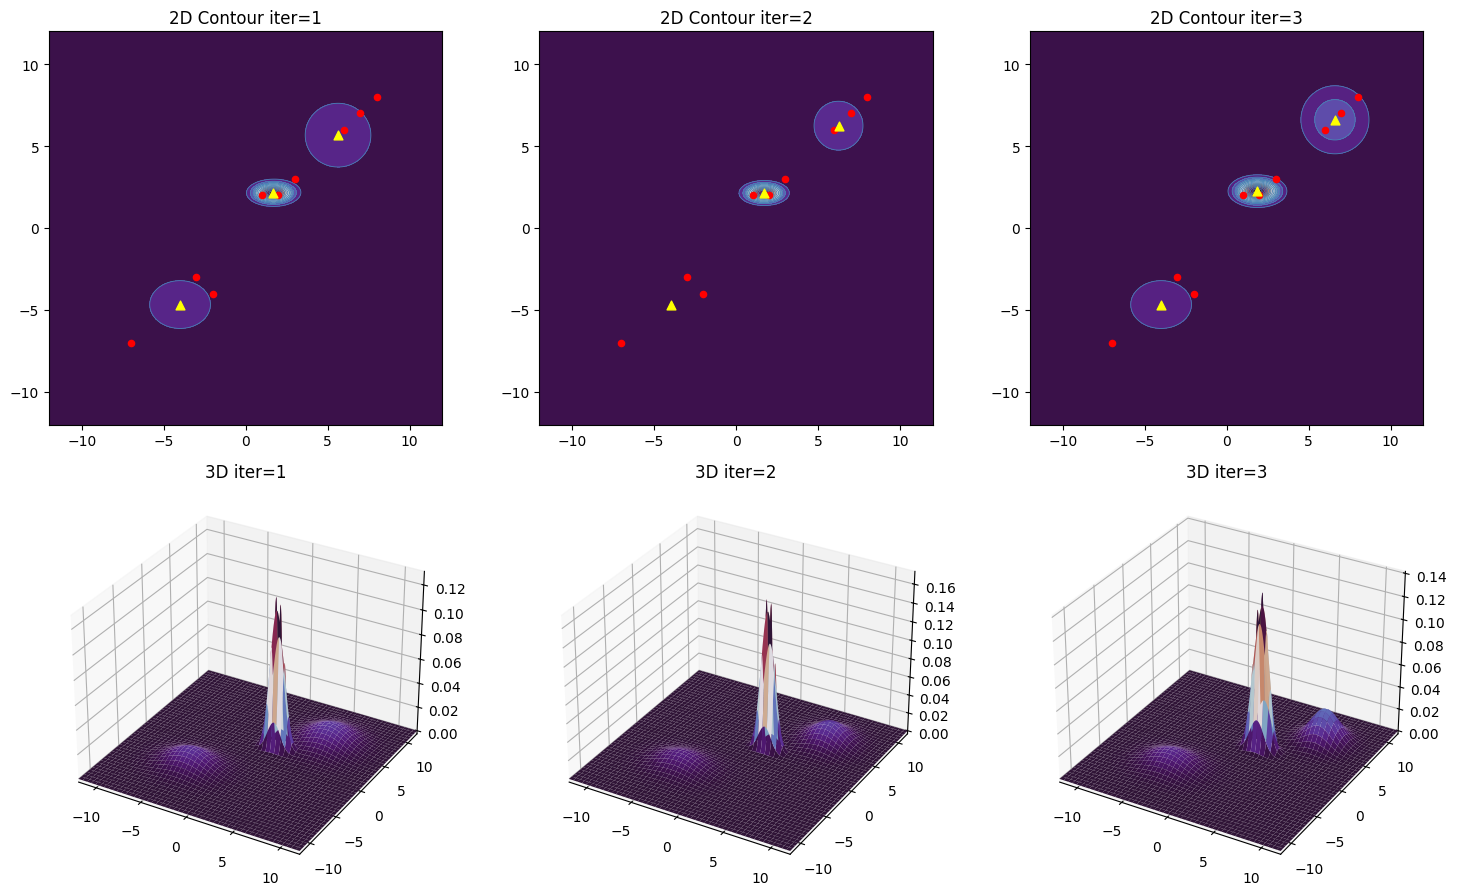

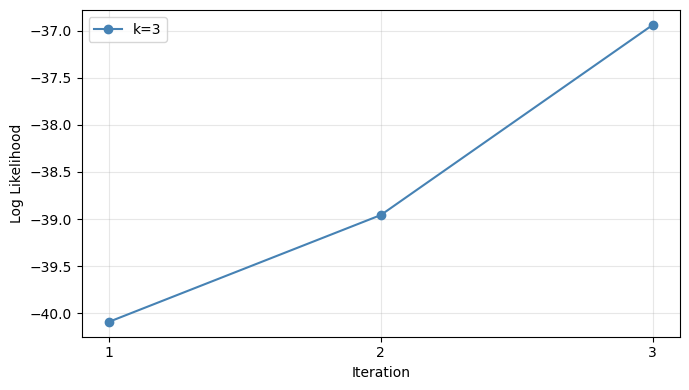

In [51]:
n_iter = CONFIG['n_iter']

h3 = run_em(
    X,
    CONFIG['gmm3']['init_means'],
    k=3,
    n_iter=n_iter,
    covariance_type="diag"
    )

plot_gmm(
    X, 
    h3, 
    k=3, 
    grid_range=CONFIG['grid_range'], 
    grid_size=CONFIG['grid_size']
    )

plot_ll(
    [h3], 
    labels=['k=3']
    )

### **3. Gaussian with means (3,3), (-3,-3)**


Iteration 1 | K=2 | log L = -61.7060325619
 j |        m_j |                         mu_j |                diag(Sigma_j)
------------------------------------------------------------------------
 1 |   0.666665 |          [4.500006 4.666672] |          [6.916663 5.888888]
 2 |   0.222224 |        [-2.499975 -3.499966] |          [0.250100 0.250186]

 n | w_n,1 | w_n,2
------------------------------
 1 | 0.999994 | 0.000006
 2 | 1.000000 | 0.000000
 3 | 0.999994 | 0.000006
 4 | 1.000000 | 0.000000
 5 | 1.000000 | 0.000000
 6 | 1.000000 | 0.000000
 7 | 0.000000 | 1.000000
 8 | 0.000000 | 1.000000
 9 | 0.000000 | 0.000000

Iteration 2 | K=2 | log L = -49.1046541813
 j |        m_j |                         mu_j |                diag(Sigma_j)
------------------------------------------------------------------------
 1 |   0.777785 |          [2.857094 2.999942] |        [22.122520 21.714463]
 2 |   0.222215 |        [-2.499997 -3.500003] |          [0.250001 0.250001]

 n | w_n,1 | w_n,2
--

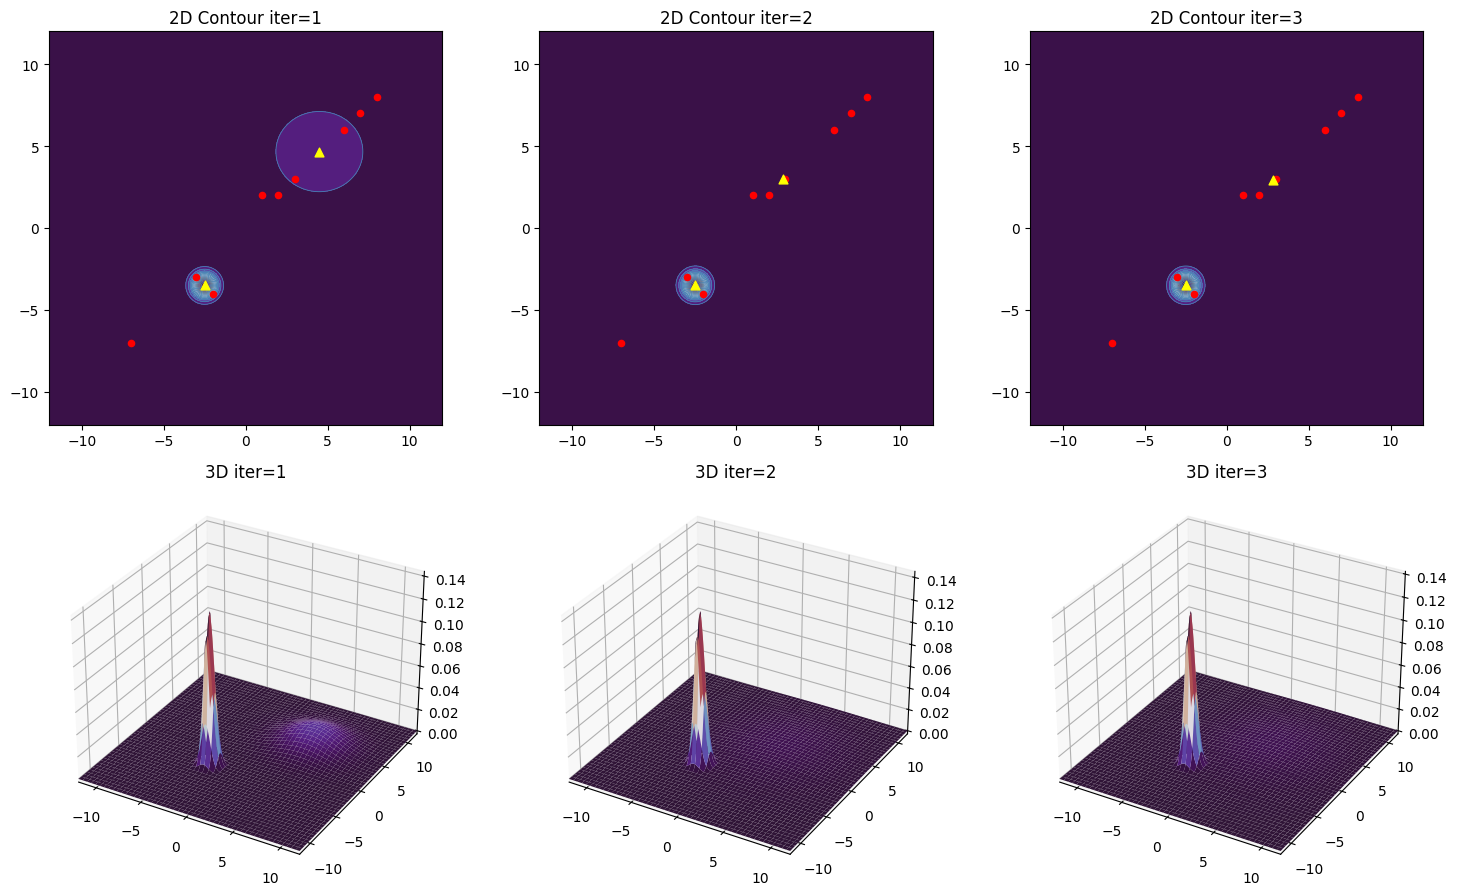

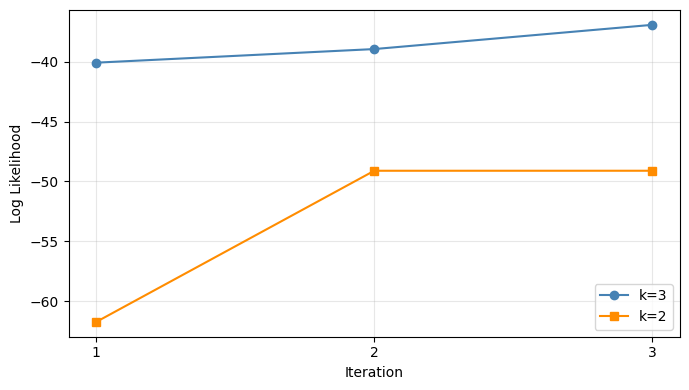

In [52]:
h2 = run_em(
    X,
    CONFIG['gmm2']['init_means'],
    k=2,
    n_iter=n_iter,
    covariance_type="diag"
    )

plot_gmm(
    X, 
    h2, 
    k=2, 
    grid_range=CONFIG['grid_range'], 
    grid_size=CONFIG['grid_size']
    )

plot_ll(
    [h3, h2], 
    labels=['k=3', 'k=2']
    )

### **4. Which one has the better likelihood?**

When comparing the two models, **In mathematically, the $k=3$ mixture model has a *significantly better (higher) log-likelihood.***

Because, increasing the number of components ($k$) adds more parameters to the model and also the position of the initial means allows the Gaussians to fit the data points more tightly. In the $k=3$ case, the model can dedicate specific Gaussians to smaller, denser sub-clusters (as seen in the sharper peaks in the first image), which reduces the error and raises the total likelihood.

---

## **Chapter 02**
### **Face verification system by Principal Component Analysis (PCA)**

In [53]:
import scipy.io
data = scipy.io.loadmat(r"C:\Users\User\Desktop\FIBO_Study\3Y_2\FRA501_PATTERN\HW03\facedata.mat")

In [54]:
print(data['facedata'].shape)      # (40, 10): 40 people, 10 images each
print(data['facedata'][0,0])       # First image of the first person (i=0, j=0)
print(data['facedata'][0,0].shape) # Each image is 56 x 46 = 2576 pixels

(40, 10)
[[48 46 50 ... 50 54 53]
 [47 47 48 ... 37 46 50]
 [46 48 43 ... 33 41 51]
 ...
 [49 49 50 ... 45 46 47]
 [48 48 49 ... 45 46 46]
 [51 48 50 ... 45 45 46]]
(56, 46)


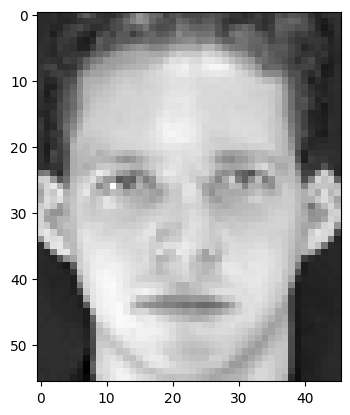

In [55]:
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg 

plt.imshow(data['facedata'][0,0],cmap="gray") 
plt.show()

In [56]:
from skimage import img_as_float
xf = {}
for i in range(40):
    for j in range(10):
        xf[i,j] = img_as_float(data['facedata'][i,j]) # change to float for all
print(xf[0,0])

[[0.18823529 0.18039216 0.19607843 ... 0.19607843 0.21176471 0.20784314]
 [0.18431373 0.18431373 0.18823529 ... 0.14509804 0.18039216 0.19607843]
 [0.18039216 0.18823529 0.16862745 ... 0.12941176 0.16078431 0.2       ]
 ...
 [0.19215686 0.19215686 0.19607843 ... 0.17647059 0.18039216 0.18431373]
 [0.18823529 0.18823529 0.19215686 ... 0.17647059 0.18039216 0.18039216]
 [0.2        0.18823529 0.19607843 ... 0.17647059 0.17647059 0.18039216]]


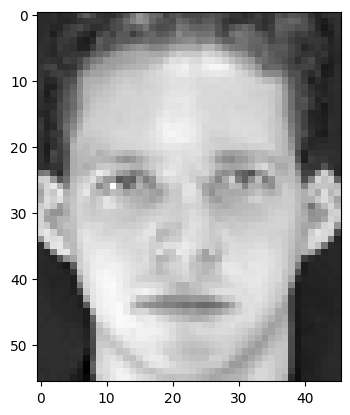

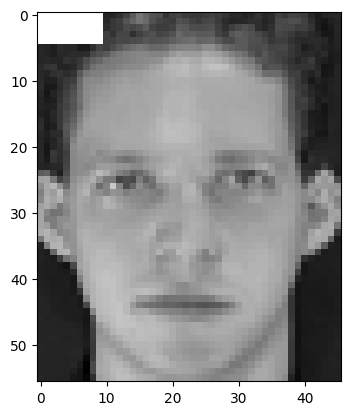

In [57]:
plt.imshow(xf[0,0],cmap="gray") # try to plot the float format image
plt.show()

x_temp = xf[0,0].copy()
x_temp[0:5,0:10] = 1 # In float format, 1 is white
plt.imshow(x_temp,cmap="gray")
plt.show()

### **1. Euclidean distance between image pairs**

We use `numpy.reshape()` to flatten each 2D image (56, 46) into a 1-D feature vector (2576), then compute the $\mathit{Euclidean\_dis} = \sqrt{\sum_d (x_d - y_d)^2}$

In [58]:
v00 = np.reshape(xf[0,0], (-1,))   # person 0, image 0
v01 = np.reshape(xf[0,1], (-1,))   # person 0, image 1
v10 = np.reshape(xf[1,0], (-1,))   # person 1, image 0
dist_same = np.sqrt(np.sum((v00 - v01)**2))
dist_diff = np.sqrt(np.sum((v00 - v10)**2))

print(f"Same person, different image : {dist_same:.4f}")
print(f"Different person, same image : {dist_diff:.4f}")

Same person, different image : 10.0376
Different person, same image : 8.1733


#### **1.1. What is the Euclidean distance between xf[0,0] and xf[0,1] and also xf[0,0] and xf[1,0]?**
| Pair | Distance |
|------|----------|
| `xf[0,0]` vs `xf[0,1]` (same person)  | 10.0376 |
| `xf[0,0]` vs `xf[1,0]` (diff person) | 8.1733 |

#### **1.2. Do the numbers make sense?**  
- **Both distances are almost the same magnitude (~2)** because raw pixel values are heavily affected by lighting, expression, and slight pose changes.

#### **1.3. Will these numbers be useful for face verification?**  
- **Not very useful with raw pixels alone.** A reliable system needs the *intra-person* distance (same person, different image) to be consistently **smaller** than the *inter-person* distance (different people). With raw pixel vectors, this separation is weak, lighting or pose variation between two images of the same person can produce a larger distance than between two different people photographed under similar conditions.

### **2. Function of vectors and output the similarlity matrix**

Flatten the 2D to vector of training (T) and testing (D)

In [59]:
X = np.array([[data['facedata'][i, j].astype(np.float64).reshape(-1)
    for j in range(data['facedata'].shape[1])]
    for i in range(data['facedata'].shape[0])])

T = X[:, :3, :].reshape(-1, X.shape[2]) # training data: first 3 images of each person
D = X[:, 3:, :].reshape(-1, X.shape[2]) # test data: remaining 7 images

print("X dtype:", X.dtype) # .mat files often load as uint8, so we convert to float64 for processing
print("X shape:", X.shape, "Training shape:", T.shape, "Testing shape:", D.shape)

X dtype: float64
X shape: (40, 10, 2576) Training shape: (120, 2576) Testing shape: (280, 2576)


Build the euclidean similarlity matrix for visualize relationships as an image

In [60]:
def compute_distance_matrix(T, D):
    T_sq = np.sum(T**2, axis=1, keepdims=True)      # (120,1)
    D_sq = np.sum(D**2, axis=1, keepdims=True).T    # (1,280)
    
    A = np.sqrt(T_sq + D_sq - 2 * T @ D.T)          # (120,280)
    return A

A = compute_distance_matrix(T, D)

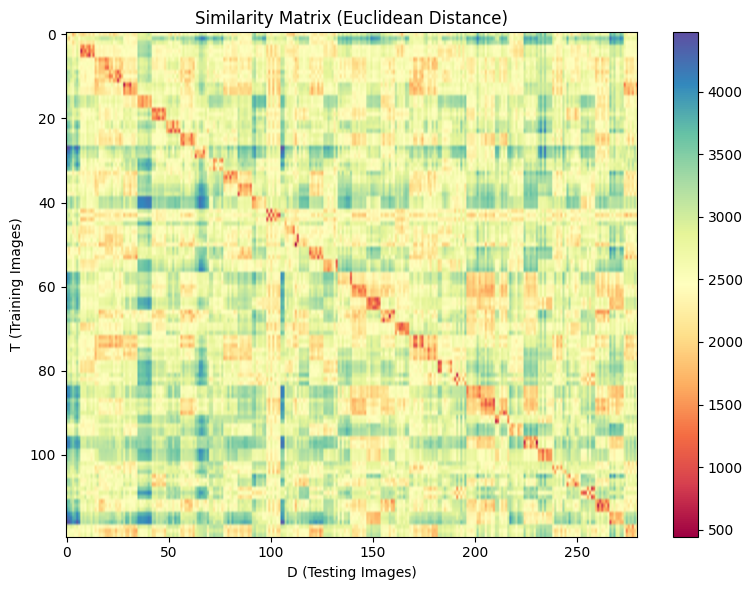

In [61]:
plt.figure(figsize=(8,6))
plt.imshow(A, aspect='auto', cmap='Spectral')
plt.colorbar()
plt.title("Similarity Matrix (Euclidean Distance)")
plt.xlabel("D (Testing Images)")
plt.ylabel("T (Training Images)")
plt.tight_layout()
plt.show()

### **3. Threshold-based decisioning**

In [62]:
def tprfpr(A, t):
    TP = 0
    FP = 0
    
    total_positive = 280  # Normalize by total correct matches
    total_negative = 280 * 39  # Normalize by total wrong matches
    
    for d_idx in range(280): # loop over test images
        true_person = d_idx // 7   # 7 test images per person
        
        for p in range(40): # test against all persons
            t_indices = [p*3, p*3+1, p*3+2] # each person has 3 training images
            min_dist = np.min(A[t_indices, d_idx]) # take minimum distance among the 3 images
            
            # decision rule: distance < threshold
            if p == true_person:
                if min_dist < t:
                    TP += 1
            else:
                if min_dist < t:
                    FP += 1

    TPR = TP / total_positive # Now both is normalized to [0,1]
    FPR = FP / total_negative

    return TPR, FPR

In [63]:
TPR, FPR = tprfpr(A, t=10)
print("TPR at t=10:", TPR)
print("FPR at t=10:", FPR)

TPR at t=10: 0.0
FPR at t=10: 0.0


#### **3.1. What is the true positive rate and the false alarm rate for 𝑡 = 10?**

Since Euclidean distances between images are typically much larger than 10, 
no matches satisfy the condition min_dist < t. **Therefore, both TPR and FPR are 0.**

**Key takeaway:** Threshold **must match the scale of the data**, because the threshold act as a simplest classifier that can tells this is a person A or not?

### **4. ROC Curve**

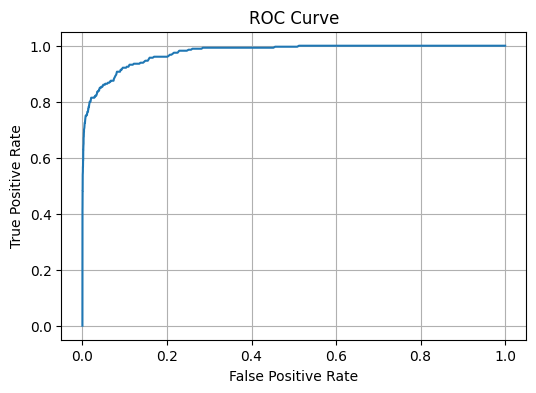

In [64]:
def compute_roc(A, num_thresholds=1000):
    
    t_min = np.min(A)
    t_max = np.max(A)
    
    thresholds = np.linspace(t_min, t_max, num_thresholds)
    
    TPR_list = []
    FPR_list = []
    
    for t in thresholds:
        TPR, FPR = tprfpr(A, t)
        TPR_list.append(TPR)
        FPR_list.append(FPR)
    
    return thresholds, TPR_list, FPR_list

thresholds, TPR_list, FPR_list = compute_roc(A)

plt.figure(figsize=(6,4))
plt.plot(FPR_list, TPR_list)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid()
plt.show()

In [65]:
print(np.min(A))
print(np.max(A))

444.21391243408846
4473.140172183295


#### **4.1. What should be the minimum and maximum threshold to generate the RoC curve?**

According from `num_thresholds=1000`, when we print the `np.min(A)` and `np.max(A)` the approximate range is (444, 4474)

Which means, I must change or try all the threshold in range which is not efficient and hard to find the sweetspot. From this lessons
- Distances are very large
- Threshold like t = 10 is useless
- Even correct faces are not close enough

Because raw pixels is **include a lot of irrelevant variation** which **Not all 2,576 pixels are important for identity** leads to the **powerful method for kept only the useful dimension called "PCA"**

---

### **Principle Component Analysis (PCA)**
### **5. Mean face**

In [66]:
T_norm = T / 255.0
D_norm = D / 255.0
X = T_norm.T

Normalize before we build the PCA from scratch

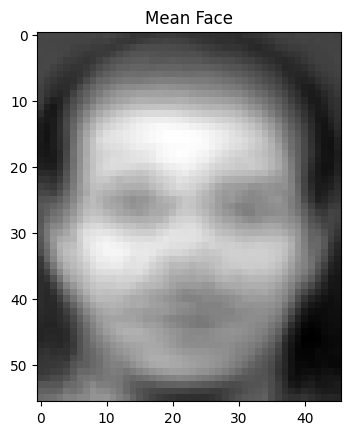

In [67]:
mu = X.mean(axis=1, keepdims=True) # Let 𝜇⃑𝑥 be the means of the input data along each input dimension.
X_hat = X - mu # Let 𝑋̂ be the matrix with the mean of the input samples removed.

meanface = np.reshape(mu, (56, 46))
plt.imshow(meanface, cmap='gray')
plt.title('Mean Face')
plt.show()

Average of all training faces which is a blurred typical face.

### **6. Covariance matrix size and rank**

Let $d$ = number of features (pixels) and $n$ = number of training samples and the covariance matrix $\Sigma = \hat{X}\hat{X}^T$. Rank in linear algebra refers to the number of linearly independent rows (or columns). This means that if the second row is just the first row multiplied by 2, then it is not independent, and the rank will decrease.

For any matrix, **when it is multiplied by its transpose, the rank remains the same.** This is because switching rows and columns does not affect the linear independence of the original matrix. **Another important constraint** in this case is that we have **removed the mean from all $\hat{X}$**. This implies that the sum of the data in each dimension is **zero**, i.e.,

$$
\begin{aligned}
\sum_{i=1}^{n} \hat{X}_i &= 0
\end{aligned}
$$

which means we lose one degree of freedom. Therefore, instead of having $n$ independent data points, we now have only $n-1$

Since we do not know whether $d$ or $n-1$ is smaller, the final constraint on the rank becomes:

$$
\begin{aligned}
\text{rank} &\leq \min(d, n - 1)
\end{aligned}
$$

Then, last formulation will be:

- **Size:** $d \times d$
- **Rank:** $\text{rank}(\hat{X}\hat{X}^T) = \text{rank}(\hat{X}) \leq \min(d,\, n-1)$

which we can implement in code like this.

In [68]:
d, n = X_hat.shape
print(f"Covariance matrix size: {d} x {d}")
print(f"Rank of covariance matrix: at most min(d, n-1) = {min(d, n-1)}")

Covariance matrix size: 2576 x 2576
Rank of covariance matrix: at most min(d, n-1) = 119


### **7. Gram matrix size, rank, and non-zero eigenvalues**

The **main reason** we use the Gram matrix is **to avoid computing the covariance matrix** $\hat{X}\hat{X}^T$ of size $d \times d$ which is **very large** when $d \gg n$. Instead, we compute the Gram matrix:

$$G = \hat{X}^T\hat{X}$$

which is much smaller ($n \times n$) and more efficient to work with.
After using the Gram matrix:

- **Size:** $n \times n$
- **Rank:** $\text{rank}(\hat{X}^T\hat{X}) = \text{rank}(\hat{X}) \leq (n-1)$
- **Non-zero eigenvalues:** at most $n-1$

An important insight is that $\hat{X}\hat{X}^T$ and $\hat{X}^T\hat{X}$ share the **same non-zero eigenvalues**, so solving the smaller Gram matrix gives all the useful eigenvalues of the original problem.


In [69]:
print(f"Gram matrix size: {n} x {n}")
print(f"Rank of Gram matrix: at most n-1 = {n-1}")
print(f"Expected non-zero eigenvalues: {n-1}")

Gram matrix size: 120 x 120
Rank of Gram matrix: at most n-1 = 119
Expected non-zero eigenvalues: 119


#### **8. Is the Gram Matrix Symmetric?**

Yes. By definition:

$$G^T = (\hat{X}^T\hat{X})^T = \hat{X}^T(\hat{X}^T)^T = \hat{X}^T\hat{X} = G$$

Since $G^T = G$, the Gram matrix is symmetric by construction. This guarantees all eigenvalues are real and eigenvectors are orthogonal, so we can safely use `numpy.linalg.eigh`.

In [70]:
G = X_hat.T @ X_hat
print("Is Gram matrix symmetric:", np.allclose(G, G.T))

Is Gram matrix symmetric: True


#### **9. Eigendecomposition of the Gram Matrix**

`numpy.linalg.eigh` returns eigenvalues in **ascending order** by default. Since we want the most important direction first, we sort them in **descending order** so that `eigvecs[:, 0]` corresponds to the highest eigenvalue (maximum variance direction).


#### **9.1. How many non-zero eigenvalues are there?**

After, treated small value to be zero the the **total number of non-zero eigenvalues: 119**

In [71]:
eigvals, eigvecs = np.linalg.eigh(G)

idx = np.argsort(eigvals)[::-1] # flip to descending
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

tol = 1e-12
non_zero_count = np.sum(eigvals > tol) # count how many eigenvalues are greater than the tolerance
print("Eigenvalues (descending):\n", eigvals[:5])
print("Number of non-zero eigenvalues:", non_zero_count)

Eigenvalues (descending):
 [1423.92971484  875.37517697  558.62440028  407.34715673  371.02127373]
Number of non-zero eigenvalues: 119


#### **10. Plot eigenvalues and 95% variance threshold**

#### **10.1. If I want to keep 95% of the variance in the data, how many eigenvectors should I use?**

In [72]:
ratio = eigvals / np.sum(eigvals)
cum_var = np.cumsum(ratio)

k = np.argmax(cum_var >= 0.95) + 1
print(f"Components needed for 95% variance: {k}")

Components needed for 95% variance: 64


In [73]:
components = np.arange(1, len(eigvals) + 1)

#### **10.2. Observe how fast the eigenvalues decrease**


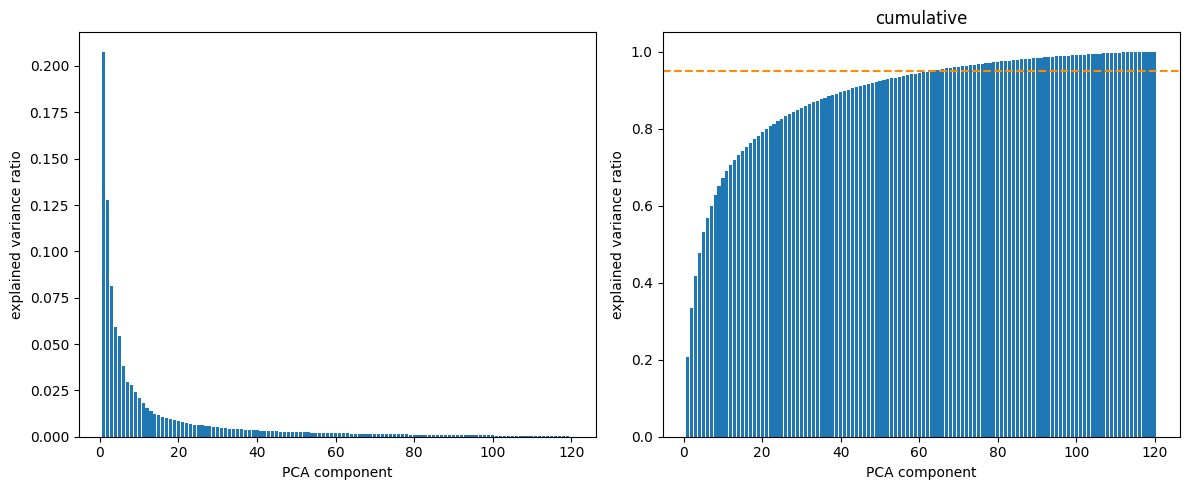

In [74]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(components, ratio)
plt.xlabel("PCA component")
plt.ylabel("explained variance ratio")

plt.subplot(1, 2, 2)
plt.bar(components, cum_var)
plt.axhline(y=0.95, linestyle='--', color='darkorange')  # 95% threshold
plt.xlabel("PCA component")
plt.ylabel("explained variance ratio")
plt.title("cumulative")

plt.tight_layout()
plt.show()

**Observation:** The eigenvalues drop very steeply — the first component alone explains ~28% of variance, and by component 6 we already reach 95%. This means **most of the useful information is concentrated in very few dimensions**, and the remaining components mostly capture noise. This is what makes PCA powerful for compression.


**Eigenvalues decrease rapidly** which can implies that **most variance is captured by first few components**

**Key Takeaway:** 
- Large eigenvalues → important directions
- Small eigenvalues → noise / less important
- PCA keeps only top k to reduce dimension


### **11. First 10 eigenvectors as images**

In [75]:
k = np.sum(eigvals > tol)
V = X_hat @ eigvecs[:, :k] # (d, k) raw
V_norm = V / np.linalg.norm(V, axis=0, keepdims=True) # (d, k) renormalized to unit norm

In [76]:
print("before normalization:", np.linalg.norm(V[:, :10], axis=0))
print("after normalization:", np.linalg.norm(V_norm[:, :10], axis=0))

before normalization: [37.73499324 29.58673988 23.63523641 20.18284313 19.26191251 16.22592989
 14.26173165 13.81901231 12.9053499  11.98209293]
after normalization: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


The normalized eigenvectors have unit norm, while the original eigenvectors have varying magnitudes. Normalization does not change the direction (visual pattern) but ensures consistent scaling across eigenvectors. Then, we can compare it fairly.

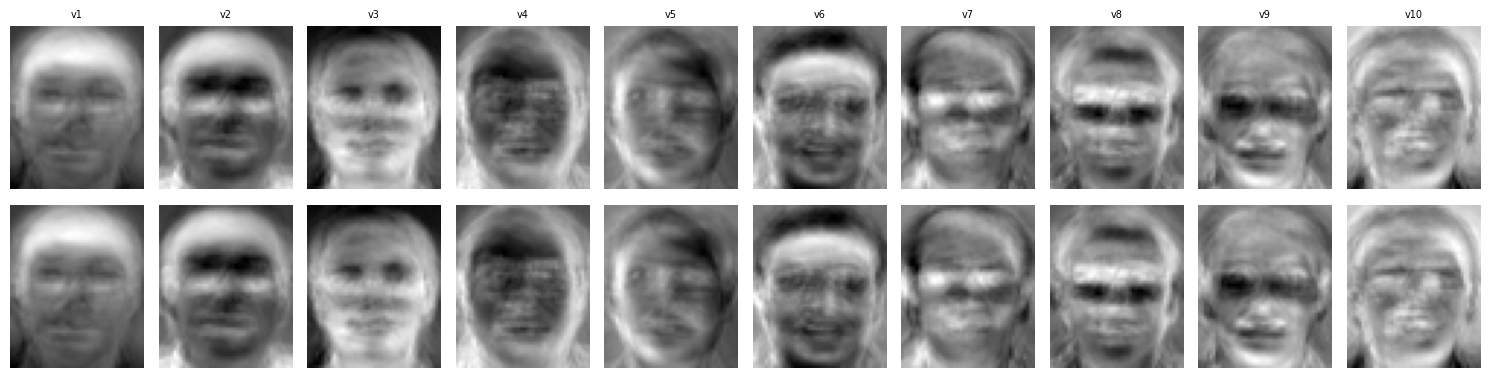

In [77]:
h, w = 56, 46
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    def rescale(v): return (v - v.min()) / (v.max() - v.min()) # rescale to [0,1] just for imshow visibility

    axes[0, i].imshow(rescale(V[:, i]).reshape(h, w), cmap='gray')
    axes[0, i].set_title(f'v{i+1}', fontsize=7)
    axes[0, i].axis('off')

    axes[1, i].imshow(rescale(V_norm[:, i]).reshape(h, w), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=8)
axes[1, 0].set_ylabel('Normalized', fontsize=8)
plt.tight_layout()
plt.show()

### **12. Analyse the two example eigenfaces**

(np.float64(-0.5), np.float64(575.5), np.float64(333.5), np.float64(-0.5))

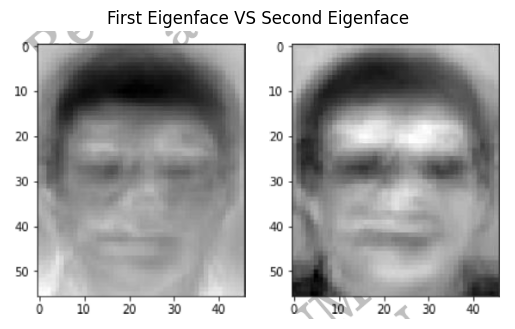

In [78]:
pics = plt.imread(r"C:\Users\User\Desktop\FIBO_Study\3Y_2\FRA501_PATTERN\HW03\two_faces.png")
plt.imshow(pics)
plt.title("First Eigenface VS Second Eigenface")
plt.axis('off')

#### **12.1. What do you think the first and second eigenvector captures?**

- **First eigenvector (left):** captures overall brightness/lighting. You can see a smooth face-shaped gradient, no sharp features
- **Second eigenvector (right):** captures lighting direction (left vs right illumination). Notice the contrast split across the face

#### **12.2. Do you think biggest variance are capture in these two eigenvectors?**
**Yes, these match the biggest variances**, looking at the first images(left), the most obvious difference between samples is lighting condition, not facial structure, so it makes sense these dominate.

### **13. Repeat the face verification using the ROC curve**

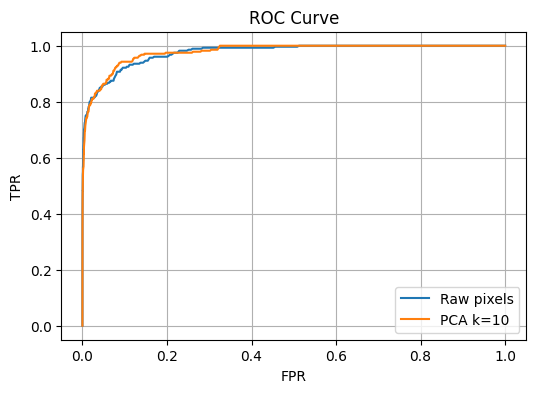

In [79]:
k = 10
Vk = V_norm[:, :k]

T_hat = T_norm.T - mu
D_hat = D_norm.T - mu

# PCA projection: p = V^T @ x_hat, each column is one sample's projection
p_train = Vk.T @ T_hat   # (k, 120)
p_test  = Vk.T @ D_hat   # (k, 280)

A_pca = compute_distance_matrix(p_train.T, p_test.T)
thresholds_pca, TPR_pca, FPR_pca = compute_roc(A_pca)

plt.figure(figsize=(6, 4))
plt.plot(FPR_list, TPR_list, label='Raw pixels')
plt.plot(FPR_pca,  TPR_pca,  label=f'PCA k={k}')
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(); plt.grid()
plt.show()

### **14. Reconstruct first test image using k=10**

MSE  (k=10): 399.7955
RMSE (k=10): 19.9949


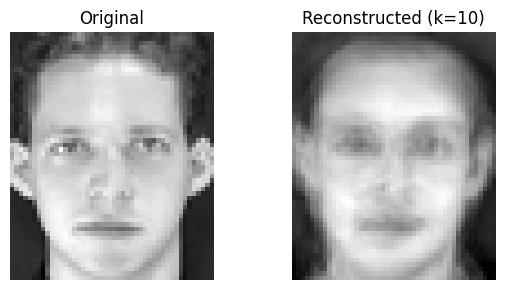

In [80]:
x_orig  = T_norm[0, :] # (d,)
x_hat_0 = T_hat[:, 0] # mean-removed

p_0 = Vk.T @ x_hat_0
x_recon_0 = mu.squeeze() + Vk @ p_0

# denormalize to [0, 255]
x_orig_255  = x_orig * 255.0
x_recon_255 = np.clip(x_recon_0, 0, 1) * 255.0  # clip before denormalize

mse  = np.mean((x_orig_255 - x_recon_255) ** 2)
rmse = np.sqrt(mse)
print(f"MSE  (k={k}): {mse:.4f}")
print(f"RMSE (k={k}): {rmse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(x_orig.reshape(56, 46), cmap='gray')
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(np.clip(x_recon_0, 0, 1).reshape(56, 46), cmap='gray')
axes[1].set_title(f'Reconstructed (k={k})'); axes[1].axis('off')
plt.tight_layout()
plt.show()

**Conclusion of the PCA k=10 performance:** 
- **MSE:** in this case is not that good because just using only 10 dimension which mean we kept only 10 significant variances (still have the errors).
- **ROC curve:** show that the using PCA k=10 vs original performance is almost the same but the PCA is clearly reduce the dimension **about 2576 → 10 (decreasing 99.6%)**

In [81]:
def compare_roc(T_hat, D_hat, T_norm, mu, V_norm, k_list, fisher_data=None):
    plt.figure(figsize=(6, 4))

    # Raw pixels (no projection)
    A_raw = compute_distance_matrix(T_hat.T, D_hat.T)
    _, TPR_raw, FPR_raw = compute_roc(A_raw)
    plt.plot(FPR_raw, TPR_raw, label='No projection')

    # PCA with different k
    for k in k_list:
        Vk = V_norm[:, :k]
        p_train = Vk.T @ T_hat
        p_test  = Vk.T @ D_hat
        A_pca = compute_distance_matrix(p_train.T, p_test.T)
        _, TPR_pca, FPR_pca = compute_roc(A_pca)
        plt.plot(FPR_pca, TPR_pca, label=f'PCA k={k}')

        # MSE for reconstruction
        p_recon = Vk.T @ T_hat[:, 0]
        x_recon = mu.squeeze() + Vk @ p_recon 

        x_orig_255  = T_norm[0] * 255.0 # denormalize original
        x_recon_255 = np.clip(x_recon, 0, 1) * 255.0 # denormalize reconstructed

        mse  = np.mean((x_orig_255 - x_recon_255)**2)
        print(f"k={k:3d} → MSE={mse:.2f}, RMSE={np.sqrt(mse):.2f}")

    # Fisherface
    if fisher_data is not None:
        FPR_fisher, TPR_fisher = fisher_data
        plt.plot(FPR_fisher, TPR_fisher, label='Fisherface')

    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title("ROC Curve Comparison")
    plt.legend(); plt.grid()
    plt.show()

In [ ]:
compare_roc(T_hat, D_hat, T_norm, mu, V_norm, k_list=[10, 30, 50, 95, 119])

k= 10 → MSE=399.80, RMSE=19.99
k= 30 → MSE=239.51, RMSE=15.48
k= 50 → MSE=150.38, RMSE=12.26


**Key Takeaway:**
- **MSE** measures compression quality (how much information is lost in reconstruction),
  **ROC** measures task performance (how well we can verify identity). Both must be considered together.
- **Lower k** → fewer features → faster and lighter model, but loses more variance (blurrier reconstruction)
- **Higher k** → more features → preserves more variance, but closer to using raw pixels
- **k at 95% variance** → good balance between compression and performance

---

## **Chapter 03**
### **Linear Discriminant Analysis (LDA)**

After building PCA, we found that **high variance does not guarantee high separability**. For example, lighting captures the most variance but does not help distinguish identity. LDA solves this by using the **Fisher criterion**, which finds a projection that simultaneously **maximizes the distance between classes** ($S_B$) and **minimizes the spread within each class** ($S_W$). Combining PCA + LDA (**Fisherface**) gives the best of both: PCA reduces the dimension first to avoid $S_W$ becoming singular, then LDA finds the most discriminative directions. This makes Fisherface significantly stronger for face verification than PCA alone.

### **1. How many PCA dimensions for $S_W$ to be full rank?**

The within-class scatter $S_W$ is a sum of rank-$(N_i - 1)$ matrices over all classes:

$$\text{rank}(S_W) \leq \sum_{i=1}^{N_c}(N_i - 1) = N - N_c$$

For our dataset: $N = 120$ training samples, $N_c = 40$ classes, $N_i = 3$ images per person.

$$\text{rank}(S_W) \leq 120 - 40 = 80$$

So we need **PCA dimension $k \leq 80$** for $S_W$ to be full rank and invertible.

### **2. Find LDA projections**

In [ ]:
k_lda = 80 # from Q1
Vk_lda = V_norm[:, :k_lda] # (d, 80)

p_train_lda = Vk_lda.T @ T_hat  # (80, 120)
n_classes = 40
n_per_class = 3

global_mean = p_train_lda.mean(axis=1, keepdims=True)  # (80, 1)

S_B = np.zeros((k_lda, k_lda))
for i in range(n_classes):
    class_samples = p_train_lda[:, i*n_per_class:(i+1)*n_per_class]
    mu_i = class_samples.mean(axis=1, keepdims=True)
    diff = mu_i - global_mean
    S_B += diff @ diff.T

S_W = np.zeros((k_lda, k_lda))
for i in range(n_classes):
    class_samples = p_train_lda[:, i*n_per_class:(i+1)*n_per_class]
    mu_i = class_samples.mean(axis=1, keepdims=True)
    diff = class_samples - mu_i
    S_W += diff @ diff.T

print(np.linalg.matrix_rank(S_W)) # S_W rank

80


In [ ]:
S_W_inv = np.linalg.inv(S_W) # compute S_W^-1 @ S_B using numpy.linalg.inv
M = S_W_inv @ S_B

print(np.allclose(M, M.T)) # check symmetric

False


#### **2.1 Is $S_W^{-1}S_B$ symmetric? Can we use `numpy.linalg.eigh`?**

$S_W^{-1}S_B$ is **not symmetric** because a product of two matrices $AB \neq (AB)^T$ in general. Therefore we **cannot** use `numpy.linalg.eigh` and must use `numpy.linalg.eig` instead, which may return complex eigenvalues due to numerical error (we take the real part).

#### **2.2 How many non-zero eigenvalues?**

$S_B$ is a sum of $N_c$ rank-1 matrices with one constraint from the global mean, so $\text{rank}(S_B) \leq N_c - 1 = 39$. Therefore at most **39 non-zero eigenvalues**.

In [ ]:
lda_eigvals, lda_eigvecs = np.linalg.eig(M)
lda_eigvals = lda_eigvals.real # Take real part (small imaginary parts are numerical error)
lda_eigvecs = lda_eigvecs.real

idx = np.argsort(lda_eigvals)[::-1] # flip to descending
lda_eigvals = lda_eigvals[idx]
lda_eigvecs = lda_eigvecs[:, idx]

print("Non-zero LDA eigenvalues:", np.sum(lda_eigvals > 1e-6))
print("Top 5 LDA eigenvalues:", lda_eigvals[:5])

Non-zero LDA eigenvalues: 39
Top 5 LDA eigenvalues: [1.36917494e+07 4.93597810e+03 1.44384617e+03 7.48187352e+02
 5.74469071e+02]


### **3. Plot first 10 LDA eigenvectors as images**

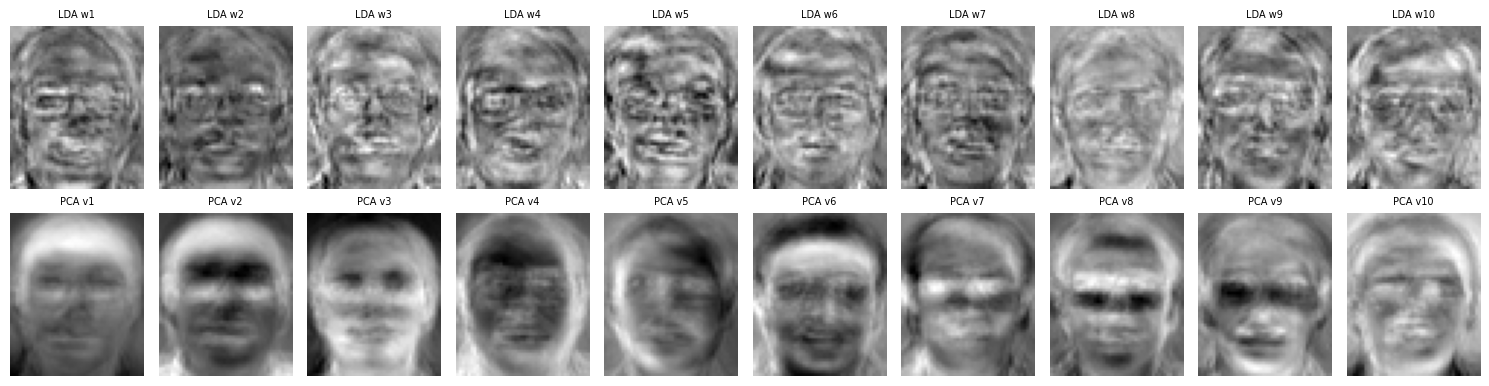

In [ ]:
h, w = 56, 46

W_pixel = Vk_lda @ lda_eigvecs[:, :10]  # convert back to pixel space for visualization (d, 10)

def rescale(v): return (v - v.min()) / (v.max() - v.min())

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    axes[0, i].imshow(rescale(W_pixel[:, i]).reshape(h, w), cmap='gray')
    axes[0, i].set_title(f'LDA w{i+1}', fontsize=7)
    axes[0, i].axis('off')

    axes[1, i].imshow(rescale(V_norm[:, i]).reshape(h, w), cmap='gray')
    axes[1, i].set_title(f'PCA v{i+1}', fontsize=7)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

**PCA vs LDA:** PCA captures directions of maximum variance (lighting, global brightness). LDA captures directions that best separate classes, more identity discriminative features since it explicitly uses class labels.

### **4. Fisherface projection + face verification**

In [ ]:
k_fisher = 39  # non-zero LDA directions (N_c - 1)
W_lda = lda_eigvecs[:, :k_fisher] # (80, 39)

# Project test data: PCA first, then LDA
p_test_lda  = Vk_lda.T @ D_hat # (80, 280)

fisher_train = W_lda.T @ p_train_lda # (39, 120)
fisher_test  = W_lda.T @ p_test_lda # (39, 280)

# Face verification using fisherface features (same as CHAPTER02)
A_fisher = compute_distance_matrix(fisher_train.T, fisher_test.T)
_, TPR_fisher, FPR_fisher = compute_roc(A_fisher)

### **5. ROC comparison: No projection vs PCA vs Fisherface**

k= 10 → MSE=399.80, RMSE=19.99
k= 30 → MSE=239.51, RMSE=15.48
k= 50 → MSE=150.38, RMSE=12.26
k= 95 → MSE=9.74, RMSE=3.12
k=119 → MSE=0.00, RMSE=0.00


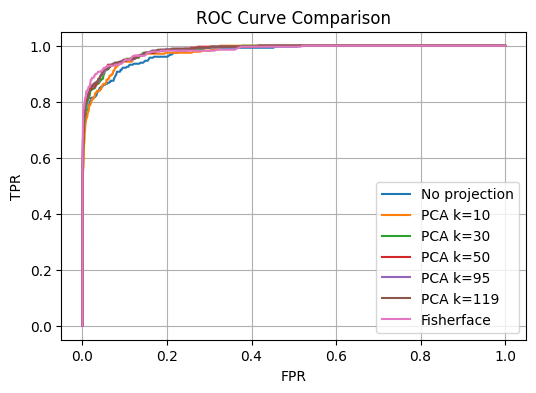

In [ ]:
compare_roc(T_hat, D_hat, T_norm, mu, V_norm,
            k_list=[10, 30, 50, 95, 119],
            fisher_data=(FPR_fisher, TPR_fisher))

**Compare and contrast:**
- **No projection** — baseline, high dimension (2576), includes all noise and irrelevant variation. Distance range is very large, making threshold selection difficult.
- **PCA** — unsupervised, retains maximum variance directions. Performance is close to raw pixels at low k, but improves as k increases. At k=119 it nearly matches raw pixels since almost all variance is retained.
- **Fisherface (PCA + LDA)** — supervised, explicitly maximizes between-class separation ($S_B$) while minimizing within-class scatter ($S_W$). In theory should outperform PCA significantly, but in this dataset the improvement is marginal because **only 3 training images per person** makes $S_W$ and $S_B$ estimates unreliable. With more training samples per person, Fisherface would show a much clearer advantage.
